In [5]:
# Cell 1 - Enhanced Imports
import os
import glob
import numpy as np
import pandas as pd
import pydicom
import scipy.ndimage
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


In [6]:
# Cell 2 - Load and Analyze Dataset
labels_df = pd.read_csv("/kaggle/input/rsna-intracranial-aneurysm-detection/train.csv")

print(f"Dataset shape: {labels_df.shape}")
print(f"Columns: {list(labels_df.columns)}")

# Analyze label distribution
label_cols = [col for col in labels_df.columns if col not in 
              ['SeriesInstanceUID', 'Modality', 'PatientAge', 'PatientSex']]

print(f"\nTarget columns ({len(label_cols)}):")
for col in label_cols:
    pos_count = labels_df[col].sum()
    print(f"  {col}: {pos_count} ({pos_count/len(labels_df)*100:.1f}%)")

# Modality distribution
print(f"\nModality distribution:")
for mod, count in labels_df['Modality'].value_counts().items():
    print(f"  {mod}: {count} ({count/len(labels_df)*100:.1f}%)")

# Check for any aneurysm present
any_aneurysm = labels_df[label_cols].sum(axis=1) > 0
print(f"\nCases with any aneurysm: {any_aneurysm.sum()} ({any_aneurysm.mean()*100:.1f}%)")

labels_df.head()

Dataset shape: (4405, 18)
Columns: ['SeriesInstanceUID', 'PatientAge', 'PatientSex', 'Modality', 'Left Infraclinoid Internal Carotid Artery', 'Right Infraclinoid Internal Carotid Artery', 'Left Supraclinoid Internal Carotid Artery', 'Right Supraclinoid Internal Carotid Artery', 'Left Middle Cerebral Artery', 'Right Middle Cerebral Artery', 'Anterior Communicating Artery', 'Left Anterior Cerebral Artery', 'Right Anterior Cerebral Artery', 'Left Posterior Communicating Artery', 'Right Posterior Communicating Artery', 'Basilar Tip', 'Other Posterior Circulation', 'Aneurysm Present']

Target columns (14):
  Left Infraclinoid Internal Carotid Artery: 79 (1.8%)
  Right Infraclinoid Internal Carotid Artery: 99 (2.2%)
  Left Supraclinoid Internal Carotid Artery: 340 (7.7%)
  Right Supraclinoid Internal Carotid Artery: 282 (6.4%)
  Left Middle Cerebral Artery: 220 (5.0%)
  Right Middle Cerebral Artery: 299 (6.8%)
  Anterior Communicating Artery: 366 (8.3%)
  Left Anterior Cerebral Artery: 46 (1

,SeriesInstanceUID,PatientAge,PatientSex,Modality,Left Infraclinoid Internal Carotid Artery,Right Infraclinoid Internal Carotid Artery,Left Supraclinoid Internal Carotid Artery,Right Supraclinoid Internal Carotid Artery,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
0,1.2.826.0.1.3680043.8.498.10004044428023505108...,64,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1.2.826.0.1.3680043.8.498.10004684224894397679...,76,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1.2.826.0.1.3680043.8.498.10005158603912009425...,58,Male,CTA,0,0,0,0,0,0,0,0,0,0,0,0,1,1
3,1.2.826.0.1.3680043.8.498.10009383108068795488...,71,Male,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1.2.826.0.1.3680043.8.498.10012790035410518400...,48,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [7]:
# Cell 3 - Enhanced DICOM Loading Function
def load_dicom_series_enhanced(series_uid, series_base="/kaggle/input/rsna-intracranial-aneurysm-detection/series"):
    """Enhanced DICOM loading with better error handling"""
    dicom_folder = os.path.join(series_base, series_uid)
    
    if not os.path.exists(dicom_folder):
        raise FileNotFoundError(f"Series folder not found: {dicom_folder}")
    
    # Get all DICOM files
    dicom_files = glob.glob(os.path.join(dicom_folder, "*.dcm"))
    if len(dicom_files) == 0:
        raise ValueError(f"No DICOM files found in {dicom_folder}")
    
    # Load DICOM files with error handling
    dicoms = []
    for f in dicom_files:
        try:
            dcm = pydicom.dcmread(f)
            if hasattr(dcm, "ImagePositionPatient") and hasattr(dcm, "pixel_array"):
                dicoms.append(dcm)
        except Exception as e:
            print(f"Warning: Could not read {f}: {e}")
            
    if len(dicoms) == 0:
        raise ValueError(f"No valid DICOMs found in {dicom_folder}")
    
    # Sort by slice position
    try:
        dicoms.sort(key=lambda x: float(x.ImagePositionPatient[2]))
    except:
        dicoms.sort(key=lambda x: int(x.get('InstanceNumber', 0)))
    
    # Extract volume
    volume = np.stack([d.pixel_array.astype(np.float32) for d in dicoms])
    
    # Get spacing
    pixel_spacing = list(map(float, dicoms[0].PixelSpacing))
    try:
        slice_thickness = float(dicoms[0].SliceThickness)
    except:
        if len(dicoms) > 1:
            positions = [float(d.ImagePositionPatient[2]) for d in dicoms]
            slice_thickness = abs(positions[1] - positions[0])
        else:
            slice_thickness = 1.0
    
    spacing = tuple(pixel_spacing + [slice_thickness])
    
    # Metadata
    metadata = {
        'Modality': dicoms[0].get('Modality', 'Unknown'),
        'SliceCount': len(dicoms),
        'SeriesDescription': dicoms[0].get('SeriesDescription', ''),
    }
    
    return volume, spacing, metadata

print("Enhanced DICOM loader defined!")

Enhanced DICOM loader defined!


In [8]:
# Cell 4 - Enhanced Preprocessing Functions
def normalize_volume_enhanced(volume, modality="CT", clip_percentiles=(1, 99)):
    """Modality-aware normalization"""
    if modality in ['CT', 'CTA']:
        # For CT, clip extreme HU values
        volume = np.clip(volume, -1000, 1000)
    else:
        # For MR, use percentile-based clipping
        low_val, high_val = np.percentile(volume, clip_percentiles)
        volume = np.clip(volume, low_val, high_val)
    
    # Z-score normalization
    mean, std = np.mean(volume), np.std(volume)
    if std > 0:
        volume = (volume - mean) / std
    
    return volume.astype(np.float32)

def resample_volume_enhanced(volume, current_spacing, target_spacing=(1.0, 1.0, 1.0)):
    """Enhanced resampling with proper axis handling"""
    # Convert spacing to z,y,x order to match volume dimensions
    spacing_zyx = current_spacing[::-1]
    target_zyx = target_spacing[::-1]
    
    resize_factor = np.array(spacing_zyx) / np.array(target_zyx)
    resampled = scipy.ndimage.zoom(volume, resize_factor, order=1)
    
    return resampled.astype(np.float32)

print("Enhanced preprocessing functions defined!")

Enhanced preprocessing functions defined!


In [9]:
# Cell 5 - Test Enhanced Loading
# Pick a sample from the dataset
sample_idx = 100  # Try different indices if this fails
sample_row = labels_df.iloc[sample_idx]
sample_uid = sample_row["SeriesInstanceUID"]

print(f"Testing with UID: {sample_uid}")
print(f"Expected modality: {sample_row['Modality']}")

try:
    # Load with enhanced function
    volume, spacing, metadata = load_dicom_series_enhanced(sample_uid)
    
    print(f"✅ Successfully loaded!")
    print(f"Volume shape: {volume.shape}")
    print(f"Voxel spacing: {spacing}")
    print(f"Metadata: {metadata}")
    
    # Show corresponding labels
    labels = sample_row.iloc[4:].to_dict()  # Skip first 4 metadata columns
    positive_labels = {k: v for k, v in labels.items() if v == 1}
    print(f"Positive labels: {positive_labels}")
    
except Exception as e:
    print(f"❌ Failed: {e}")
    print("Trying next sample...")

Testing with UID: 1.2.826.0.1.3680043.8.498.10266003979013435429766532229856562416
Expected modality: MRA
✅ Successfully loaded!
Volume shape: (104, 384, 384)
Voxel spacing: (0.78125, 0.78125, 0.79999995231628)
Metadata: {'Modality': 'MR', 'SliceCount': 104, 'SeriesDescription': 'cemra pre'}
Positive labels: {}


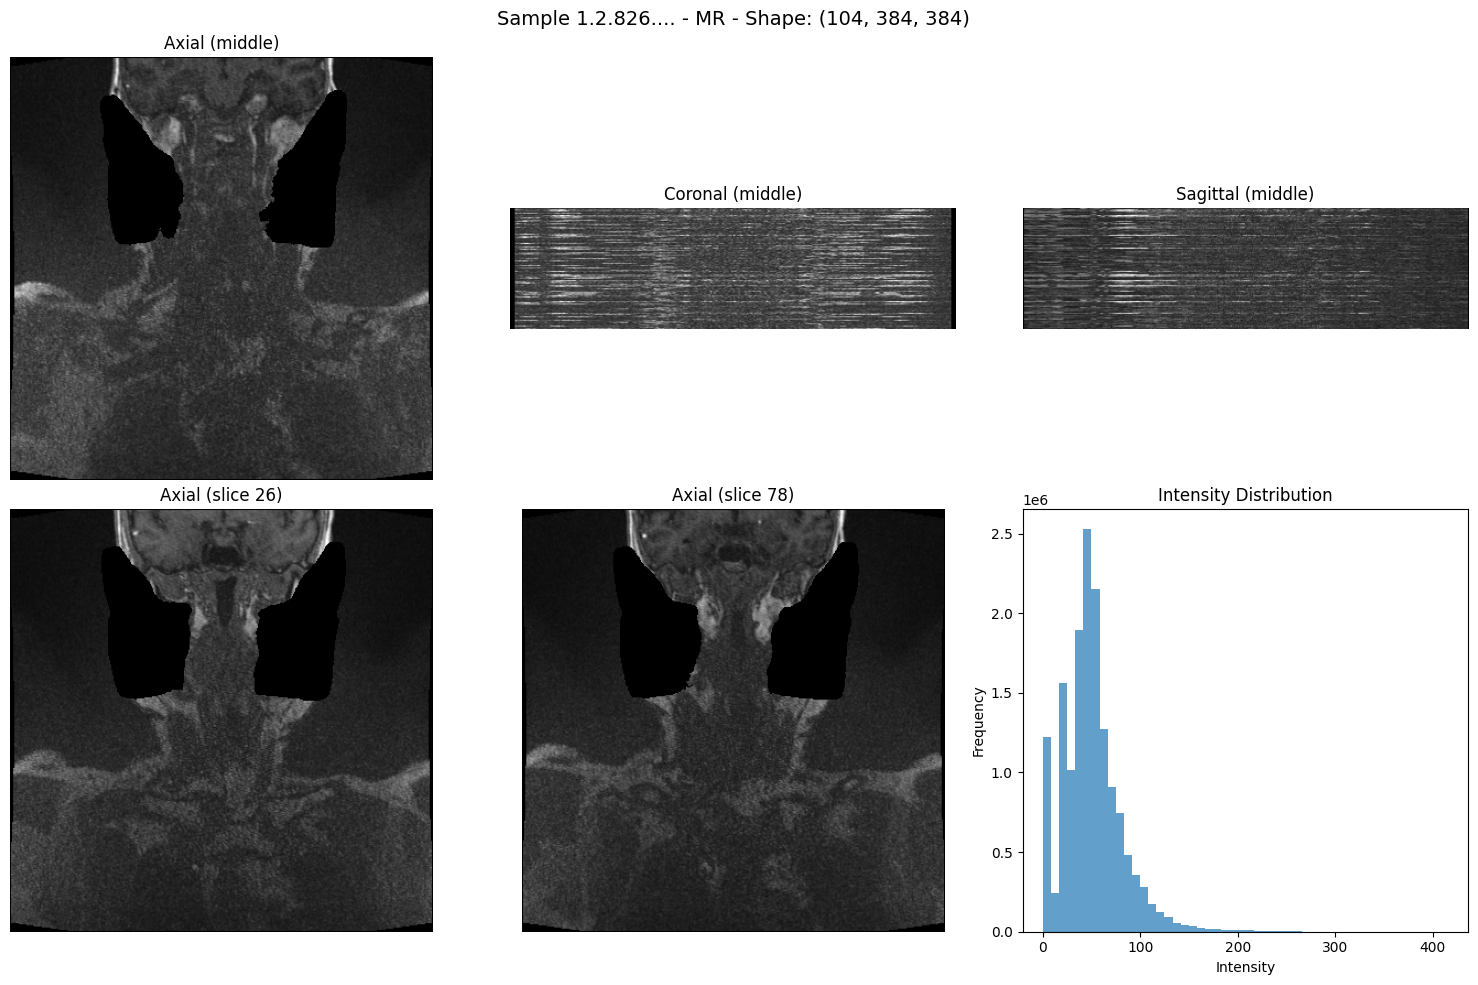

In [10]:
# Cell 6 - Enhanced Volume Visualization
def visualize_volume_enhanced(volume, metadata, title_prefix=""):
    """Enhanced visualization with metadata"""
    
    # Calculate middle slices for different views
    mid_z = volume.shape[0] // 2
    mid_y = volume.shape[1] // 2  
    mid_x = volume.shape[2] // 2
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Top row - middle slices
    axes[0,0].imshow(volume[mid_z], cmap='gray')
    axes[0,0].set_title('Axial (middle)')
    axes[0,0].axis('off')
    
    axes[0,1].imshow(volume[:, mid_y, :], cmap='gray')
    axes[0,1].set_title('Coronal (middle)')
    axes[0,1].axis('off')
    
    axes[0,2].imshow(volume[:, :, mid_x], cmap='gray')
    axes[0,2].set_title('Sagittal (middle)')
    axes[0,2].axis('off')
    
    # Bottom row - different slices
    quarter_z = volume.shape[0] // 4
    axes[1,0].imshow(volume[quarter_z], cmap='gray')
    axes[1,0].set_title(f'Axial (slice {quarter_z})')
    axes[1,0].axis('off')
    
    three_quarter_z = 3 * volume.shape[0] // 4
    axes[1,1].imshow(volume[three_quarter_z], cmap='gray')
    axes[1,1].set_title(f'Axial (slice {three_quarter_z})')
    axes[1,1].axis('off')
    
    # Intensity histogram
    axes[1,2].hist(volume.flatten(), bins=50, alpha=0.7)
    axes[1,2].set_title('Intensity Distribution')
    axes[1,2].set_xlabel('Intensity')
    axes[1,2].set_ylabel('Frequency')
    
    title = f"{title_prefix} - {metadata['Modality']} - Shape: {volume.shape}"
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# Test visualization if we have a loaded volume
if 'volume' in locals():
    visualize_volume_enhanced(volume, metadata, f"Sample {sample_uid[:8]}...")

In [8]:
# Cell 7 - Setup Batch Processing
output_dir = "/kaggle/working/processed_volumes"
os.makedirs(output_dir, exist_ok=True)

def process_series_batch(series_uids, max_count=20):
    """Process a batch of series with enhanced pipeline"""
    processed_data = []
    
    for i, uid in enumerate(tqdm(series_uids[:max_count], desc="Processing")):
        try:
            # Load volume
            volume, spacing, metadata = load_dicom_series_enhanced(uid)
            
            # Get modality from labels
            series_row = labels_df[labels_df['SeriesInstanceUID'] == uid].iloc[0]
            modality = series_row['Modality']
            
            # Process volume
            volume_norm = normalize_volume_enhanced(volume, modality)
            
            # Optional: resample (comment out if you want original spacing)
            # volume_norm = resample_volume_enhanced(volume_norm, spacing)
            
            # Save processed volume
            output_path = os.path.join(output_dir, f"{uid}.npy")
            np.save(output_path, volume_norm)
            
            # Collect metadata
            record = {
                'SeriesInstanceUID': uid,
                'FilePath': output_path,
                'OriginalShape': volume.shape,
                'ProcessedShape': volume_norm.shape,
                'Spacing': spacing,
                'Modality': modality,
                **series_row.iloc[4:].to_dict()  # Add all labels
            }
            processed_data.append(record)
            
        except Exception as e:
            print(f"Failed processing {uid}: {e}")
    
    return pd.DataFrame(processed_data)

# Test with first 10 series
test_uids = labels_df['SeriesInstanceUID'].head(10).tolist()
processed_df = process_series_batch(test_uids, max_count=10)

print(f"Successfully processed: {len(processed_df)} series")
if len(processed_df) > 0:
    processed_df.head()

Processing:  50%|█████     | 5/10 [00:28<00:26,  5.31s/it]

Failed processing 1.2.826.0.1.3680043.8.498.10012790035410518400400834395242853657: No valid DICOMs found in /kaggle/input/rsna-intracranial-aneurysm-detection/series/1.2.826.0.1.3680043.8.498.10012790035410518400400834395242853657


Processing: 100%|██████████| 10/10 [01:27<00:00,  8.76s/it]

Successfully processed: 9 series


In [4]:
# Check if processed files exist
import os

# Check for processed volumes directory
proc_dir = "/kaggle/working/processed_volumes"
if os.path.exists(proc_dir):
    npy_files = [f for f in os.listdir(proc_dir) if f.endswith('.npy')]
    print(f"Found {len(npy_files)} processed .npy files")
    if len(npy_files) > 0:
        print("First few files:")
        for f in npy_files[:5]:
            print(f"  {f}")
else:
    print("No processed volumes directory found")

# Check for any CSV files
working_files = os.listdir("/kaggle/working/")
csv_files = [f for f in working_files if f.endswith('.csv')]
print(f"CSV files in working: {csv_files}")

No processed volumes directory found
CSV files in working: []


In [1]:
# Cell 8 - Save Processing Metadata
if len(processed_df) > 0:
    metadata_path = "/kaggle/working/processed_metadata.csv"
    processed_df.to_csv(metadata_path, index=False)
    print(f"Metadata saved to: {metadata_path}")
    
    # Quick analysis
    print(f"\nProcessed data summary:")
    print(f"Modalities: {processed_df['Modality'].value_counts().to_dict()}")
    
    # Check for positive cases
    label_cols = [col for col in processed_df.columns if col not in 
                  ['SeriesInstanceUID', 'FilePath', 'OriginalShape', 'ProcessedShape', 
                   'Spacing', 'Modality', 'PatientAge', 'PatientSex']]
    
    any_positive = processed_df[label_cols].sum(axis=1) > 0
    print(f"Series with positive labels: {any_positive.sum()}/{len(processed_df)}")

NameError: name 'processed_df' is not defined

In [ ]:
# Next Steps: Scale Up Processing and Start Model Development

# Cell 9 - Scale Up Processing (Run this to process more data)
print("🚀 Ready to scale up processing!")
print("\nOptions for next steps:")

print("\n1. SCALE UP PROCESSING:")
print("   - Change max_count=10 to max_count=100 (or more)")
print("   - Process different modalities separately")
print("   - Full dataset processing")

print("\n2. EXPLORE YOUR PROCESSED DATA:")
print("   - Load and visualize the .npy files")
print("   - Check volume shapes and intensities")
print("   - Analyze positive vs negative cases")

print("\n3. BASELINE MODEL DEVELOPMENT:")
print("   - Start with 2D slice-based approach") 
print("   - Build 3D CNN for volume processing")
print("   - Implement the weighted loss function")

# Let's first explore what we have
import numpy as np

# Load one of your processed volumes
processed_files = [f for f in os.listdir('/kaggle/working/processed_volumes') if f.endswith('.npy')]
print(f"\n📁 You have {len(processed_files)} processed volumes ready!")

if len(processed_files) > 0:
    # Load metadata to see what we have
    metadata_df = pd.read_csv('/kaggle/working/processed_metadata.csv')
    print(f"\n📋 Processed Series Summary:")
    print(f"   • Total series: {len(metadata_df)}")
    print(f"   • Positive cases: {metadata_df[[col for col in metadata_df.columns if 'Aneurysm' in col or 'Artery' in col]].sum(axis=1).sum()} locations")
    print(f"   • Modalities: {dict(metadata_df['Modality'].value_counts())}")
    
    # Check volume shapes
    shapes = metadata_df['ProcessedShape'].value_counts()
    print(f"   • Volume shapes: {len(shapes)} unique shapes")
    
    # Load a sample volume
    sample_file = processed_files[0]
    sample_uid = sample_file.replace('.npy', '')
    sample_vol = np.load(f'/kaggle/working/processed_volumes/{sample_file}')
    
    print(f"\n📊 Sample Volume Analysis ({sample_uid[:20]}...):")
    print(f"   • Shape: {sample_vol.shape}")
    print(f"   • Data type: {sample_vol.dtype}")
    print(f"   • Value range: [{sample_vol.min():.2f}, {sample_vol.max():.2f}]")
    print(f"   • Memory usage: {sample_vol.nbytes / 1024**2:.1f} MB")

print(f"\n🎯 RECOMMENDED IMMEDIATE NEXT STEPS:")
print(f"1. Visualize one of your processed volumes")
print(f"2. Scale processing to 50-100 series") 
print(f"3. Start developing your baseline model")
print(f"4. Set up proper train/validation splits")


In [ ]:
# Cell 10 - Visualize Processed Volume
# =====================================

def visualize_processed_volume(volume_path, metadata_df, max_slices=3):
    """Visualize a processed volume with its labels"""
    
    # Load volume
    volume = np.load(volume_path)
    uid = os.path.basename(volume_path).replace('.npy', '')
    
    # Get metadata
    meta_row = metadata_df[metadata_df['SeriesInstanceUID'] == uid].iloc[0]
    
    # Get positive labels
    label_cols = [col for col in metadata_df.columns if col not in 
                  ['SeriesInstanceUID', 'FilePath', 'OriginalShape', 'ProcessedShape', 
                   'Spacing', 'Modality', 'PatientAge', 'PatientSex']]
    
    positive_labels = []
    for col in label_cols:
        if meta_row[col] == 1:
            positive_labels.append(col)
    
    # Create visualization
    fig, axes = plt.subplots(2, max_slices, figsize=(15, 8))
    
    # Select slices to show
    slice_indices = [
        volume.shape[0] // 4,
        volume.shape[0] // 2,
        3 * volume.shape[0] // 4
    ][:max_slices]
    
    for i, slice_idx in enumerate(slice_indices):
        # Top row: original slices
        axes[0, i].imshow(volume[slice_idx], cmap='gray')
        axes[0, i].set_title(f'Slice {slice_idx}/{volume.shape[0]}')
        axes[0, i].axis('off')
        
        # Bottom row: enhanced visualization
        axes[1, i].imshow(volume[slice_idx], cmap='gray')
        axes[1, i].contour(volume[slice_idx], levels=5, colors='red', alpha=0.3)
        axes[1, i].set_title(f'Enhanced View')
        axes[1, i].axis('off')
    
    # Title with metadata
    title = f"{meta_row['Modality']} - Shape: {volume.shape}"
    if positive_labels:
        title += f"\n🎯 Positive: {', '.join(positive_labels[:3])}"
        if len(positive_labels) > 3:
            title += f" (+{len(positive_labels)-3} more)"
    else:
        title += "\n❌ No aneurysms"
        
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return positive_labels

# Test visualization if we have processed data
if 'metadata_df' in locals() and len(processed_files) > 0:
    print("\n🖼️ Visualizing your first processed volume:")
    sample_path = f'/kaggle/working/processed_volumes/{processed_files[0]}'
    labels = visualize_processed_volume(sample_path, metadata_df)
    print(f"Found labels: {labels}")

In [ ]:
# =====================================
# Cell 11 - Scale Up Processing
# =====================================

print(f"\n📈 SCALE UP OPTIONS:")
print(f"Option A - Process 50 more series:")
print(f"   next_batch = labels_df['SeriesInstanceUID'].iloc[10:60].tolist()")
print(f"   processed_df_2 = process_series_batch(next_batch, max_count=50)")

print(f"\nOption B - Process by modality:")
print(f"   cta_series = labels_df[labels_df['Modality'] == 'CTA']['SeriesInstanceUID'].head(25)")
print(f"   mra_series = labels_df[labels_df['Modality'] == 'MRA']['SeriesInstanceUID'].head(25)")

print(f"\nOption C - Process positive cases first:")
print(f"   positive_series = labels_df[labels_df['Aneurysm Present'] == 1]['SeriesInstanceUID'].head(30)")

print(f"\n🎯 Choose your next step based on your goals:")
print(f"   • Quick baseline model → Process 50-100 mixed series")  
print(f"   • Modality comparison → Process equal numbers of each modality")
print(f"   • Class balance → Process equal positive and negative cases")

In [ ]:
# ================================================
# CELL 12 - BALANCED DATASET PROCESSING (CORRECTED)
# ================================================

print("🚀 CELL 12: Starting Balanced Dataset Processing")
print("="*60)

# Get positive and negative series
print("📊 Selecting balanced cases...")
balanced_positive = labels_df[labels_df['Aneurysm Present'] == 1]['SeriesInstanceUID'].head(50)
balanced_negative = labels_df[labels_df['Aneurysm Present'] == 0]['SeriesInstanceUID'].head(50)

print(f"✅ Selected {len(balanced_positive)} positive cases")
print(f"✅ Selected {len(balanced_negative)} negative cases")

# Combine into single batch
balanced_batch = balanced_positive.tolist() + balanced_negative.tolist()
print(f"🎯 Total batch size: {len(balanced_batch)} series")

# Verify we have the processing function
if 'process_series_batch' not in globals():
    print("❌ ERROR: process_series_batch function not found!")
    print("Please re-run Cell 7 to define the function")
else:
    print("✅ Processing function ready")
    print(f"⏱️  Expected time: ~{len(balanced_batch) * 0.2:.1f} minutes")
    print(f"💾 Expected storage: ~{len(balanced_batch) * 50:.0f} MB")
    print("\n🚀 STARTING PROCESSING...")
    print("-" * 40)
    
    # THE ACTUAL PROCESSING CALL
    balanced_df = process_series_batch(balanced_batch, max_count=100)

In [ ]:
# ================================================
# CELL 13 - ANALYZE PROCESSED RESULTS (CORRECTED) 
# ================================================

print("\n" + "="*60)
print("📊 CELL 13: Analyzing Processed Results")
print("="*60)

# Check if processing completed successfully
if 'balanced_df' in locals() and len(balanced_df) > 0:
    print(f"🎉 SUCCESS! Processed {len(balanced_df)} series")
    
    # Save the balanced metadata
    balanced_metadata_path = "/kaggle/working/balanced_metadata.csv"
    balanced_df.to_csv(balanced_metadata_path, index=False)
    print(f"💾 Saved metadata: {balanced_metadata_path}")
    
    # Analyze results
    print(f"\n📈 PROCESSING RESULTS:")
    print(f"   Success rate: {len(balanced_df)}/100 ({len(balanced_df)}%)")
    print(f"   Failed series: {100 - len(balanced_df)}")
    
    # Check modality distribution
    modality_dist = balanced_df['Modality'].value_counts()
    print(f"\n🏥 MODALITY DISTRIBUTION:")
    for mod, count in modality_dist.items():
        print(f"   {mod}: {count} series ({count/len(balanced_df)*100:.1f}%)")
    
    # Check positive vs negative
    label_cols = [col for col in balanced_df.columns if col not in 
                  ['SeriesInstanceUID', 'FilePath', 'OriginalShape', 'ProcessedShape', 
                   'Spacing', 'Modality', 'PatientAge', 'PatientSex']]
    
    aneurysm_present = balanced_df['Aneurysm Present'].sum() if 'Aneurysm Present' in balanced_df.columns else 0
    print(f"\n🎯 LABEL DISTRIBUTION:")
    print(f"   Positive cases (Aneurysm Present): {aneurysm_present}")
    print(f"   Negative cases: {len(balanced_df) - aneurysm_present}")
    print(f"   Balance ratio: {aneurysm_present/len(balanced_df)*100:.1f}% positive")
    
    # Check file sizes and shapes
    if len(balanced_df) > 0:
        sample_files = [f for f in os.listdir('/kaggle/working/processed_volumes') if f.endswith('.npy')]
        total_files = len(sample_files)
        
        print(f"\n📁 FILE ANALYSIS:")
        print(f"   Total .npy files: {total_files}")
        
        # Sample file size analysis
        if total_files > 0:
            sample_file = os.path.join('/kaggle/working/processed_volumes', sample_files[0])
            sample_size_mb = os.path.getsize(sample_file) / (1024**2)
            estimated_total_gb = (sample_size_mb * total_files) / 1024
            
            print(f"   Sample file size: {sample_size_mb:.1f} MB")
            print(f"   Estimated total size: {estimated_total_gb:.2f} GB")
    
    # Show sample of processed data
    print(f"\n📋 SAMPLE PROCESSED DATA:")
    display(balanced_df[['SeriesInstanceUID', 'Modality', 'ProcessedShape', 'Aneurysm Present']].head())
    
    print(f"\n🚀 NEXT STEPS:")
    print(f"✅ You now have {len(balanced_df)} balanced training samples!")
    print(f"✅ Ready for model development")
    print(f"✅ Consider processing more data or starting baseline model")
    
else:
    print("❌ No processed data found. Check Cell 12 execution.")
    print("If processing failed, try:")
    print("1. Re-run Cell 7 to ensure functions are defined")
    print("2. Check for memory/disk space issues")
    print("3. Try smaller batch size (max_count=25)")

print("\n" + "="*60)